In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
url = "/content/weatherAUS.csv"
df = pd.read_csv(url)
#a la hora de solo ejecutar un df.head() no muestra todas las columnas de datosm me di cuenta a la hora de abrir el csv como excel
pd.set_option('display.max_columns', None)
print(df.head())

         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am WindDir3pm  WindSpeed9am  \
0           W           44.0          W        WNW          20.0   
1         WNW           44.0        NNW        WSW           4.0   
2         WSW           46.0          W        WSW          19.0   
3          NE           24.0         SE          E          11.0   
4           W           41.0        ENE         NW           7.0   

   WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  Pressure3pm  Cloud9am  \
0          24.0         71.0         22.0      

In [4]:
df.info()
#con esto podemos entender que tenemos 142.193 entradas de datos, pero que en ciertas categorias como
# Evaporation-Sunshine-Cloud9am-Cloud9pm entre otros hay una gran cantidad de datos que no estan registrados o estan en nan, que significa a la hora de querer hacer analisi
#de datos tendremos que quitar esos datos vacios para poder tener un mejor entendimiento del manejo de datos, pero en otros como Date-Location estan completos



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115556 entries, 0 to 115555
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           115556 non-null  object 
 1   Location       115556 non-null  object 
 2   MinTemp        114990 non-null  float64
 3   MaxTemp        115273 non-null  float64
 4   Rainfall       114265 non-null  float64
 5   Evaporation    65255 non-null   float64
 6   Sunshine       60158 non-null   float64
 7   WindGustDir    106565 non-null  object 
 8   WindGustSpeed  106589 non-null  float64
 9   WindDir9am     106865 non-null  object 
 10  WindDir3pm     112010 non-null  object 
 11  WindSpeed9am   114284 non-null  float64
 12  WindSpeed3pm   113012 non-null  float64
 13  Humidity9am    113925 non-null  float64
 14  Humidity3pm    112840 non-null  float64
 15  Pressure9am    105653 non-null  float64
 16  Pressure3pm    105690 non-null  float64
 17  Cloud9am       72698 non-null

In [6]:
df.shape

(115556, 24)

# empezamos con un ejemplo sencillo, si segun los datos registrados, al dia siguiente lloverá o no.

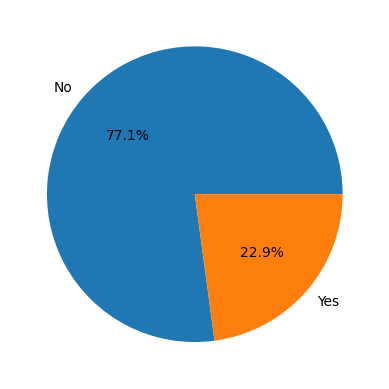

In [7]:
plt.pie(df.RainTomorrow.value_counts(), labels=df.RainTomorrow.value_counts().index, autopct='%1.1f%%') #el autopct='%1.1f%%' solo hace que muestre el % dentro de la tabla
plt
plt.show()

#Luego quise intentar mostrar un grafico en el cual se pudiese apreciar cuales son las localizaciones donde llovia x dia (no confundir con cantidad de lluvia caida por dia)

pero se veia demasiada informacion y realmente no se logra de entender del todo


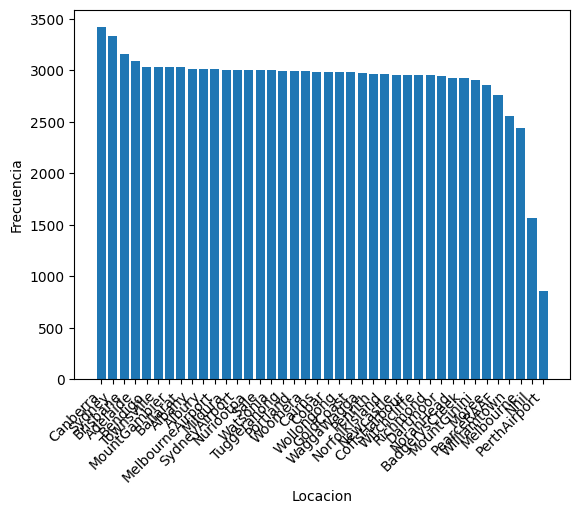

In [8]:
valores_nacionalidades = df.Location.value_counts()
etiquetas_nacionalidades = df.Location.value_counts().index
plt.bar(
    etiquetas_nacionalidades , valores_nacionalidades)
plt.xticks(rotation = 45, ha = 'right')
plt.xlabel('Locacion')
plt.ylabel('Frecuencia')
plt.show()

#aqui separe datos, para poder mostrar si se podria comparar mas los lugares que llovio mas o menos, pero seguia siendo de todas maneras demasiado confuso

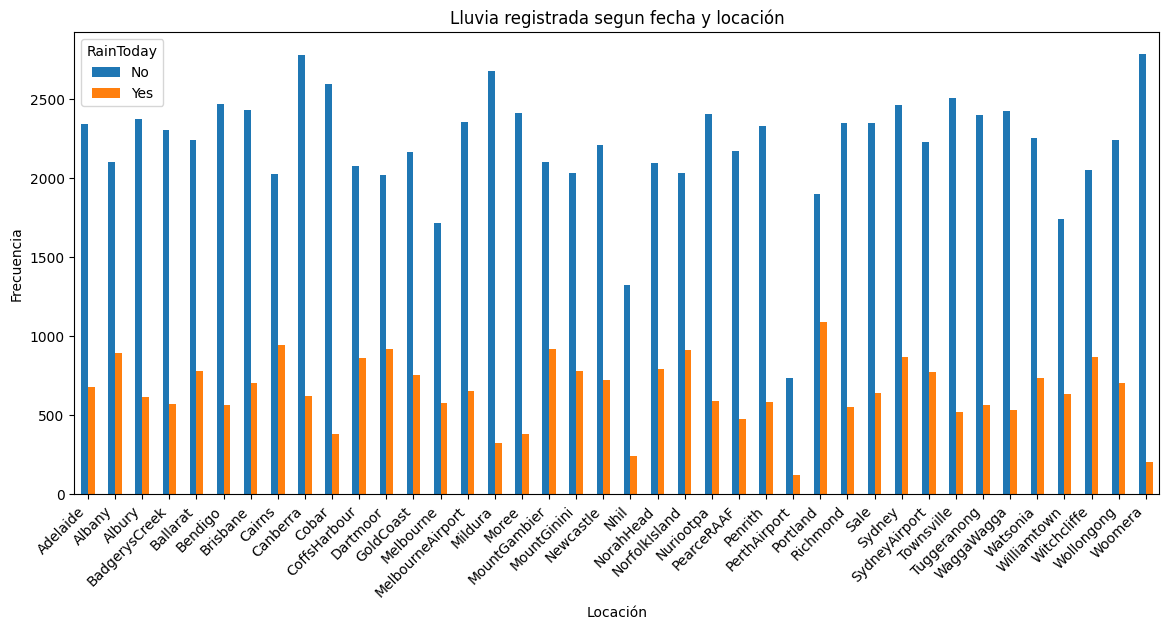

In [9]:
valores_lluvia_hoy = df.groupby(['Location', 'RainToday']).size().unstack()

valores_lluvia_hoy.plot(kind='bar', figsize=(14,6))
plt.xticks(rotation=45, ha='right')
plt.xlabel('Locación')
plt.ylabel('Frecuencia')
plt.title('Lluvia registrada segun fecha y locación')
plt.legend(title='RainToday')
plt.show()

#Asi que lo deje contando solo cuando rainToday era igual a "yes", con un head de 10 para que me muestre solo 10 datos y con sort_value para que se ordene de mayor a menor, me dice que la locacion donde mas veces registradas lluvias es en Portland

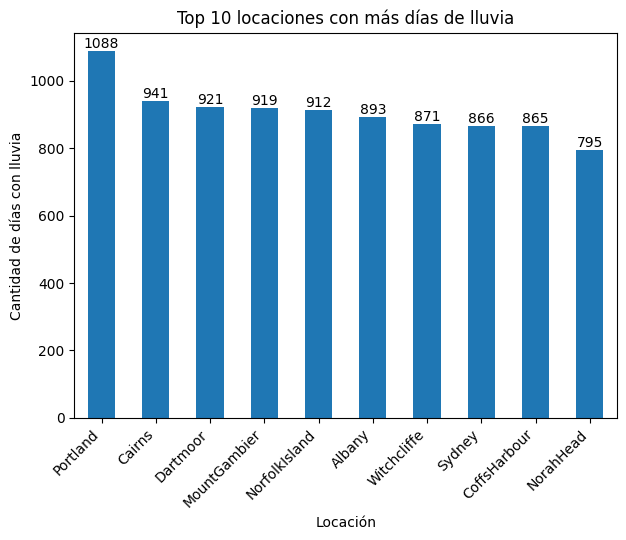

In [10]:
lluvia_por_locacion = df[df['RainToday'] == 'Yes']['Location'].value_counts().sort_values(ascending=False)
ax = lluvia_por_locacion.head(10).plot(kind='bar', figsize=(7,5))

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

plt.title('Top 10 locaciones con más días de lluvia')
plt.xlabel('Locación')
plt.ylabel('Cantidad de días con lluvia')
plt.xticks(rotation=45, ha='right')
plt.show()

#quiero saber todas las localicaciones

In [12]:
df_copia = df.copy() #en caso de que haya errores o que quiera modificar y asi no matar el df ksadjhjkas
localicaciones = df_copia.Location.value_counts()
print(localicaciones.index)

Index(['Canberra', 'Sydney', 'Brisbane', 'Adelaide', 'Bendigo', 'Townsville',
       'MountGambier', 'Ballarat', 'Albany', 'Albury', 'MelbourneAirport',
       'Mildura', 'SydneyAirport', 'Nuriootpa', 'Sale', 'Watsonia',
       'Tuggeranong', 'Portland', 'Woomera', 'Cairns', 'Cobar', 'Wollongong',
       'GoldCoast', 'WaggaWagga', 'Penrith', 'NorfolkIsland', 'Newcastle',
       'CoffsHarbour', 'Witchcliffe', 'Richmond', 'Dartmoor', 'NorahHead',
       'BadgerysCreek', 'MountGinini', 'Moree', 'PearceRAAF', 'Williamtown',
       'Melbourne', 'Nhil', 'PerthAirport'],
      dtype='object', name='Location')


#Voy a utilizar Sydney, Portland, GoldCoast, Nhil y Melbourne para comparar

(114265, 24)
Location
Sydney       11093.0
GoldCoast    10903.4
Portland      7552.6
Melbourne     4223.2
Nhil          1460.0
Name: Rainfall, dtype: float64


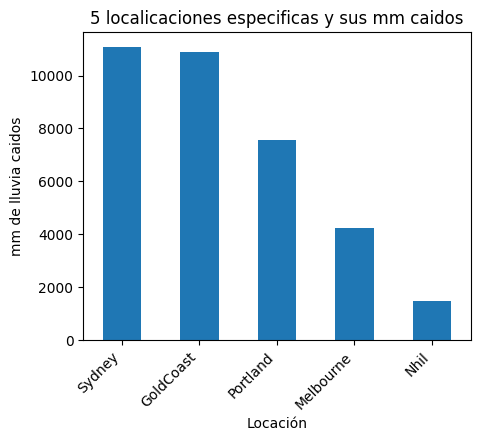

In [33]:
df2 = df.dropna(subset=['Rainfall'])
print(df2.shape)


locaciones = ['Sydney', 'Portland', 'GoldCoast', 'Nhil', 'Melbourne']

df_filtrado = df2[df2['Location'].isin(locaciones)]
lluvia_mm = df_filtrado.groupby('Location')['Rainfall'].sum()
lluvia_mm = lluvia_mm.sort_values(ascending=False)
print(lluvia_mm)

lluvia_mm.plot(kind='bar', figsize=(5,4))
plt.title('5 localicaciones especificas y sus mm caidos')
plt.xlabel('Locación')
plt.ylabel('mm de lluvia caidos')
plt.xticks(rotation=45, ha='right')
plt.show()


Se puede intuir que la localicaion que mas mm caidos en los registros es GoldCoas y la que obtuvo menos fue Nhil

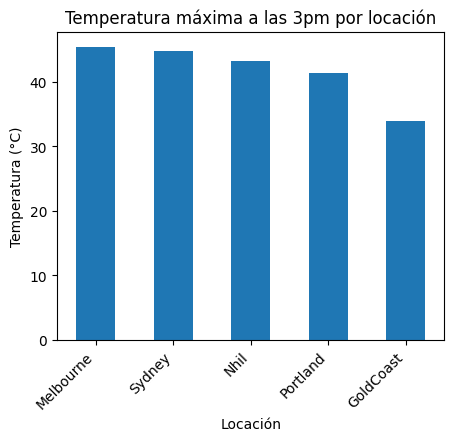

In [32]:
df3 = df.dropna(subset=['Temp3pm']) #borramos los datos nan de la temperatura de la tarde

locaciones = ['Sydney', 'Portland', 'GoldCoast', 'Nhil', 'Melbourne']

df_filtrado = df3[df3['Location'].isin(locaciones)]

temp_max = df_filtrado.groupby('Location')['Temp3pm'].max()
temp_max = temp_max.sort_values(ascending=False)



locaciones = ['Sydney', 'Portland', 'GoldCoast', 'Nhil', 'Melbourne']

df_filtrado = df3[df3['Location'].isin(locaciones)]

temp_max = df_filtrado.groupby('Location')['Temp3pm'].max()
temp_max = temp_max.sort_values(ascending=False)

temp_max.plot(kind='bar', figsize=(5,4))

plt.title('Temperatura máxima a las 3pm por locación')
plt.xlabel('Locación')
plt.ylabel('Temperatura (°C)')
plt.xticks(rotation=45, ha='right')
plt.show()

# Aca podemos apreciar que de estas 5 ciudades, en sus dias mas calurosos 4/5 fueron mayores a 40°, y que la mayor temperatura obtenida de Goldcoast es la mas baja en esta comparativa

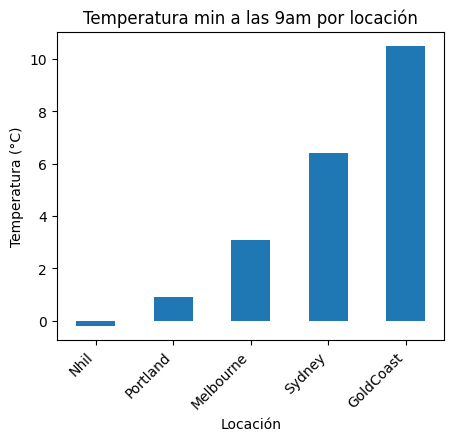

In [31]:
df4 = df.dropna(subset=['Temp9am']) #borramos los datos nan de la temperatura de la mañana

locaciones = ['Sydney', 'Portland', 'GoldCoast', 'Nhil', 'Melbourne']

df_filtrado = df4[df4['Location'].isin(locaciones)]

temp_min = df_filtrado.groupby('Location')['Temp9am'].min()
temp_min = temp_min.sort_values(ascending=False)



locaciones = ['Sydney', 'Portland', 'GoldCoast', 'Nhil', 'Melbourne']

df_filtrado = df4[df4['Location'].isin(locaciones)]

temp_min = df_filtrado.groupby('Location')['Temp9am'].min()
temp_min = temp_min.sort_values(ascending=True)

temp_min.plot(kind='bar', figsize=(5,4))

plt.title('Temperatura min a las 9am por locación')
plt.xlabel('Locación')
plt.ylabel('Temperatura (°C)')
plt.xticks(rotation=45, ha='right')
plt.show()